<a href="https://colab.research.google.com/github/LourdesBranchi/vision-por-computadora-tp2/blob/main/TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

# 1. Lectura del video

In [3]:
VIDEO_PATH = '/content/drive/MyDrive/CEIA - UBA/3B/VPC/TPs/TP2/focus_video.mov'

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video cargado correctamente")
print(f"  Resolución : {width} x {height} px")
print(f"  FPS        : {fps:.2f}")
print(f"  Frames     : {total_frames}")
print(f"  Duración   : {total_frames/fps:.2f} s")

cap.release()

Video cargado correctamente
  Resolución : 640 x 360 px
  FPS        : 29.97
  Frames     : 171
  Duración   : 5.71 s


# 2. Funcion que calcula el algoritmo de FM

Se calcula la métrica FM (*Image Quality Measure*) propuesta en el paper provisto por la cátedra.

In [4]:
def compute_FM(image_gray: np.ndarray):
    """
    Calcula el Image Quality Measure (FM) según el paper:
    'Image Sharpness Measure for Blurred Images in Frequency Domain'.

    Argumentos
    ----------
    image_gray : np.ndarray  —> imagen en escala de grises (uint8 o float)

    Devuelve
    -------
    FM    : (float) valor escalar de calidad de imagen (mayor = más enfocada)
    debug : (dict) variables intermedias útiles para inspección/visualización
    """

    # ── Tamaño de la imagen ──────────────────────────────────────────
    M, N = image_gray.shape          # M filas (alto), N columnas (ancho)

    # ── Paso 1: Transformada de Fourier 2D ───────────────────────────
    # np.fft.fft2 descompone la imagen en sus componentes de frecuencia. Una imagen desenfocada pierde energía en las altas frecuencias.
    F = np.fft.fft2(image_gray.astype(np.float64))

    # ── Paso 2: Centrar el espectro ──────────────────────────────────
    # Por defecto fft2 ubica la frecuencia cero en la esquina (0,0).
    # fftshift mueve ese origen al centro de la imagen, dejando las bajas frecuencias en el medio y las altas en la periferia.
    # Es lo que el paper llama Fc.
    Fc = np.fft.fftshift(F)

    # ── Paso 3: Espectro de amplitud (magnitud) ──────────────────────
    # abs(Fc) calcula la magnitud de cada Fc, lo que el paper llama AF (Absolute value of centered Fourier).
    AF = np.abs(Fc)

    # ── Paso 4: Valor máximo del espectro ────────────────────────────
    # M_max es el pico global de energía espectral. Es la referencia para definir el umbral.
    M_max = np.max(AF)

    # ── Paso 5: Umbral y conteo de píxeles relevantes ────────────────
    # thres = M/1000  es el umbral propuesto por el paper.
    # T_H = cantidad de píxeles cuya magnitud supera ese umbral.
    # En una imagen nítida hay muchas frecuencias altas con energía → T_H grande.
    # En una imagen borrosa casi todo se concentra en baja frecuencia → T_H chico.
    thres = M_max / 1000.0
    T_H   = np.sum(AF > thres)

    # ── Paso 6: Image Quality Measure ────────────────────────────────
    # FM = T_H / (M×N)  normaliza por el total de píxeles.
    FM = T_H / (M * N)

    debug = {
        "M": M, "N": N,
        "F": F, "Fc": Fc, "AF": AF,
        "M_max": M_max, "thres": thres, "T_H": T_H
    }

    return FM, debug

# 3. Inspección de cómo funciona el algoritmo

Hacemos pruebas en dos frames para inspeccionar como funciona el algoritmo.
En base al video, se eligen el primer frame (baja calidad de imagen) y el frame de la mitad del video (alta calidad de imagen)

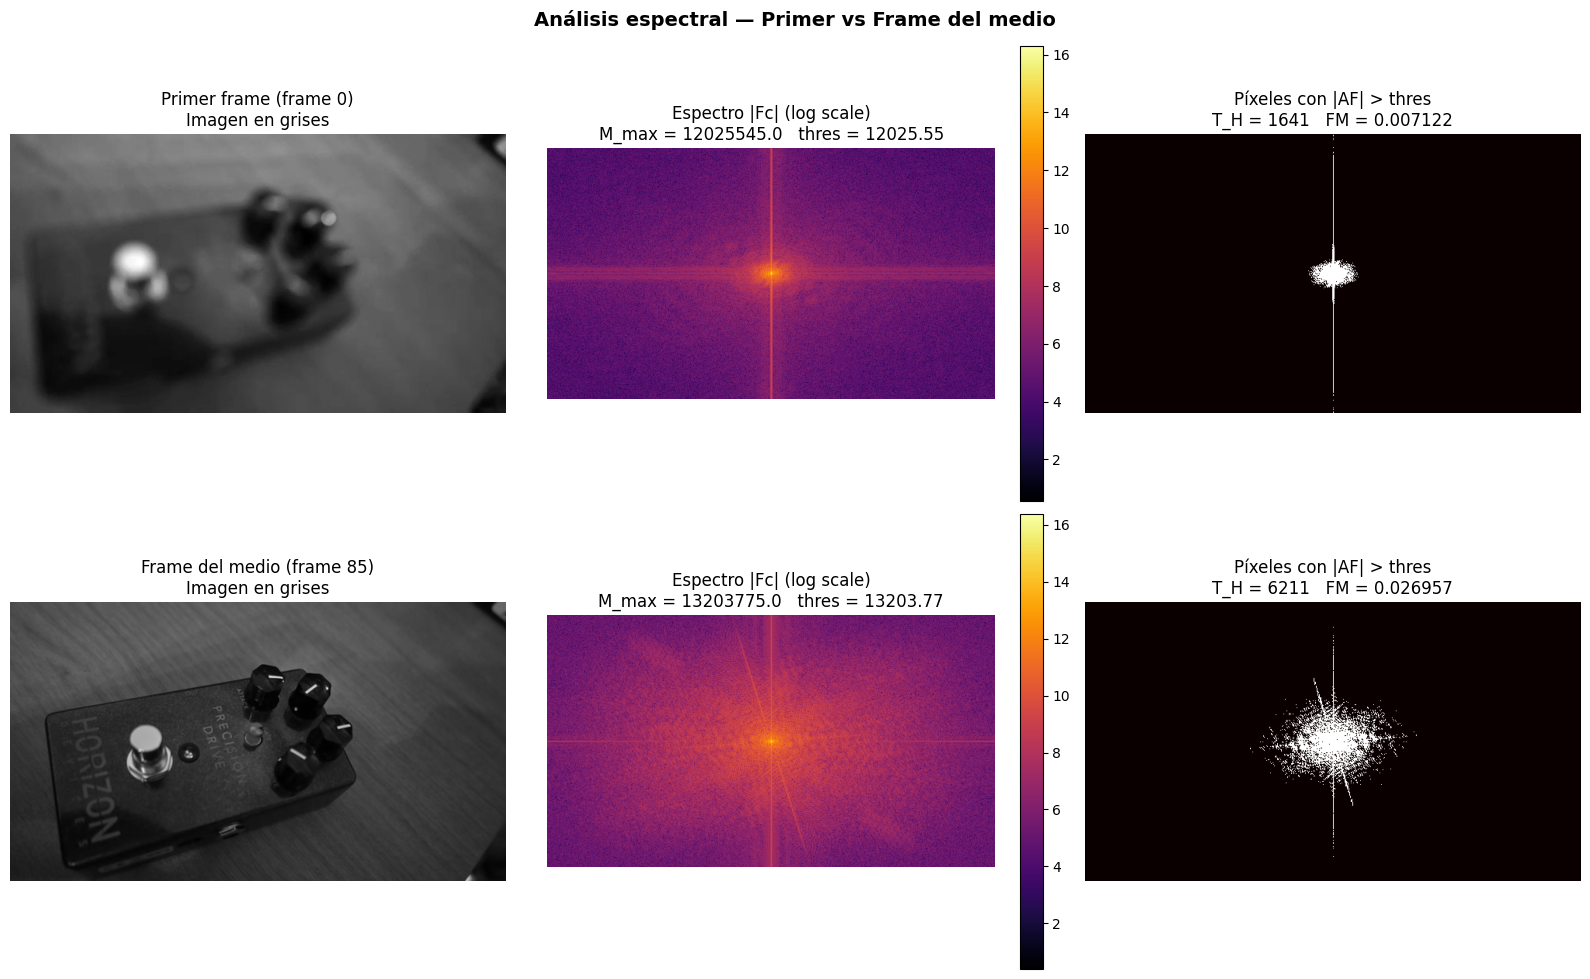



                             Primer frame Frame del medio
─────────────────────────────────────────────────────────
  Frame #                               0              85
  T_H                                1641            6211
  FM                             0.007122        0.026957

→ Frame con mayor enfoque: Frame del medio (FM = 0.026957)


In [6]:
# ── Leemos el primer y el último frame ──────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

frames_to_analyze = {
    "Primer frame": 0,
    "Frame del medio": total_frames // 2
}

samples = {}
for label, idx in frames_to_analyze.items():
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError(f"No se pudo leer el frame {idx}")
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fm, dbg = compute_FM(gray)
    samples[label] = {"idx": idx, "gray": gray, "fm": fm, "dbg": dbg}

cap.release()

# ── Figura comparativa: 2 frames × 3 paneles ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Análisis espectral — Primer vs Frame del medio", fontsize=14, fontweight="bold")

for row, (label, data) in enumerate(samples.items()):
    dbg = data["dbg"]
    fm  = data["fm"]
    idx = data["idx"]

    # Panel 1: imagen en grises
    axes[row, 0].imshow(data["gray"], cmap="gray")
    axes[row, 0].set_title(f"{label} (frame {idx})\nImagen en grises")
    axes[row, 0].axis("off")

    # Panel 2: espectro log
    log_AF = np.log1p(dbg["AF"])
    im = axes[row, 1].imshow(log_AF, cmap="inferno")
    axes[row, 1].set_title(f"Espectro |Fc| (log scale)\nM_max = {dbg['M_max']:.1f}   thres = {dbg['thres']:.2f}")
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)

    # Panel 3: máscara de píxeles sobre el umbral
    mask = (dbg["AF"] > dbg["thres"]).astype(np.uint8)
    axes[row, 2].imshow(mask, cmap="hot")
    axes[row, 2].set_title(f"Píxeles con |AF| > thres\nT_H = {dbg['T_H']}   FM = {fm:.6f}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

# ── Resumen comparativo ──────────────────────────────────────────────
print("\n")
print(f"{'':25} {'Primer frame':>15} {'Frame del medio':>15}")
print("─" * 57)
keys = [("idx",     "Frame #"),
        ("T_H",     "T_H"),
        ("fm",      "FM")]

for key, nombre in keys:
    v1 = samples["Primer frame"]["dbg"].get(key) or samples["Primer frame"].get(key)
    v2 = samples["Frame del medio"]["dbg"].get(key) or samples["Frame del medio"].get(key)
    if isinstance(v1, float):
        print(f"  {nombre:23} {v1:>15.6f} {v2:>15.6f}")
    else:
        print(f"  {nombre:23} {v1:>15} {v2:>15}")

mejor = max(samples, key=lambda k: samples[k]["fm"])
print(f"\n→ Frame con mayor enfoque: {mejor} (FM = {samples[mejor]['fm']:.6f})")

Notamos que tanto el T_H como el FM del Frame del medio es mayor que para el primer frame.

# 4. Experimentos

## 4.1 Experimento 1: FM calculado sobre todo el frame

Procesando frames (frame completo)...
  Frame    0/171  FM = 0.007122
  Frame   50/171  FM = 0.012713
  Frame  100/171  FM = 0.027053
  Frame  150/171  FM = 0.007218

✅ Procesamiento completo
   Frame de MÁXIMO ENFOQUE : 109
   FM máximo               : 0.028624


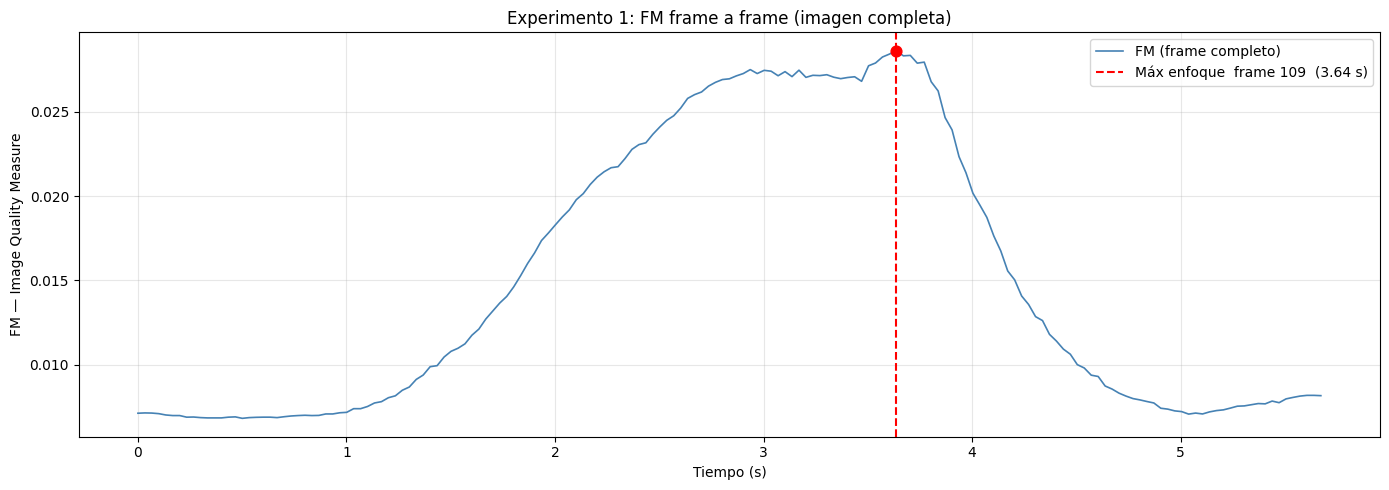

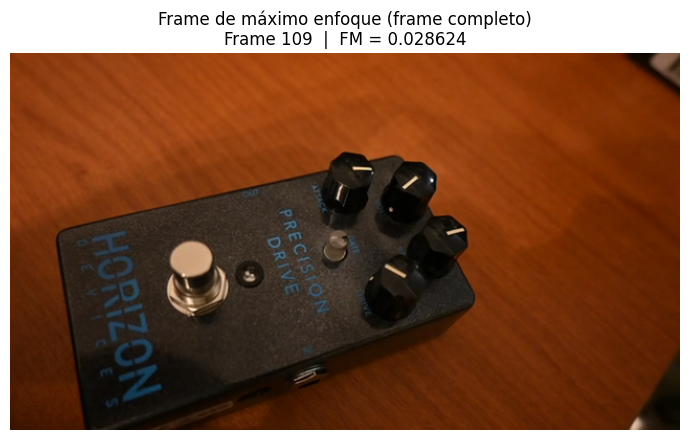

In [13]:
# ── Procesamos todos los frames ──────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fm_values_full = []   # FM por frame
frame_idx      = 0

print("Procesando frames (frame completo)...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fm, _ = compute_FM(gray)
    fm_values_full.append(fm)

    if frame_idx % 50 == 0:
        print(f"  Frame {frame_idx:4d}/{total_frames}  FM = {fm:.6f}")

    frame_idx += 1

cap.release()

fm_values_full = np.array(fm_values_full)
best_frame_full = int(np.argmax(fm_values_full))

print(f"\n✅ Procesamiento completo")
print(f"   Frame de MÁXIMO ENFOQUE : {best_frame_full}")
print(f"   FM máximo               : {fm_values_full[best_frame_full]:.6f}")

# ── Gráfica de la curva FM ───────────────────────────────────────────
time_axis = np.arange(len(fm_values_full)) / fps   # eje en segundos

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_axis, fm_values_full, color="steelblue", linewidth=1.2, label="FM (frame completo)")
ax.axvline(best_frame_full / fps, color="red", linestyle="--", linewidth=1.5,
           label=f"Máx enfoque  frame {best_frame_full}  ({best_frame_full/fps:.2f} s)")
ax.scatter([best_frame_full / fps], [fm_values_full[best_frame_full]],
           color="red", zorder=5, s=60)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("FM — Image Quality Measure")
ax.set_title("Experimento 1: FM frame a frame (imagen completa)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Mostramos el frame de máximo enfoque ────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_full)
_, best_bgr_full = cap.read()
cap.release()

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(best_bgr_full, cv2.COLOR_BGR2RGB))
plt.title(f"Frame de máximo enfoque (frame completo)\nFrame {best_frame_full}  |  FM = {fm_values_full[best_frame_full]:.6f}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 4.2 Experimento 2: FM calculado sobre el ROI central de 5% del frame

ROI central (5% del área):
  Tamaño frame : 640 x 360  (230400 px)
  Tamaño ROI   : 143 x 80  (11440 px)
  Porcentaje   : 4.97%
  Coords       : filas [140:220]  columnas [248:391]

Procesando frames (ROI 5%)...
  Frame    0/171  FM_ROI = 0.070804
  Frame   50/171  FM_ROI = 0.083392
  Frame  100/171  FM_ROI = 0.416783
  Frame  150/171  FM_ROI = 0.077797

✅ Procesamiento completo
   Frame de MÁXIMO ENFOQUE (ROI): 111
   FM máximo                     : 0.465909


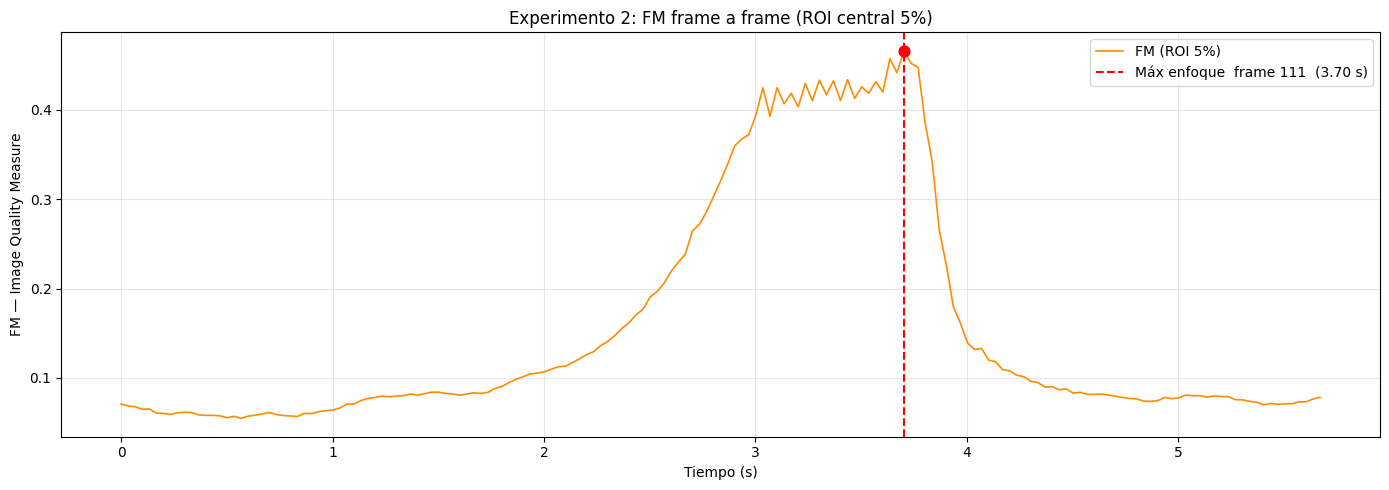

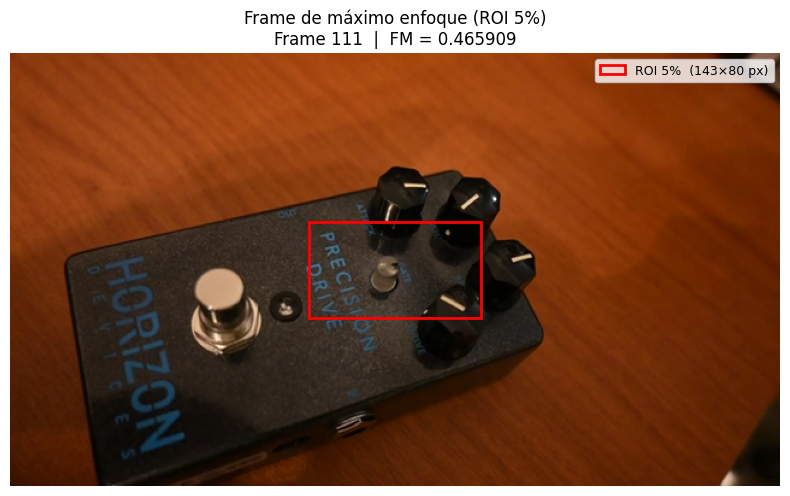

In [15]:
# ── Definición de la ROI central al 5% del área total ───────────────
roi_ratio = 0.05
roi_h = int(height * np.sqrt(roi_ratio))
roi_w = int(width  * np.sqrt(roi_ratio))

r0 = (height - roi_h) // 2
c0 = (width  - roi_w) // 2
r1 = r0 + roi_h
c1 = c0 + roi_w

print(f"ROI central (5% del área):")
print(f"  Tamaño frame : {width} x {height}  ({width*height} px)")
print(f"  Tamaño ROI   : {roi_w} x {roi_h}  ({roi_w*roi_h} px)")
print(f"  Porcentaje   : {roi_w*roi_h/(width*height)*100:.2f}%")
print(f"  Coords       : filas [{r0}:{r1}]  columnas [{c0}:{c1}]")

# ── Procesamos todos los frames usando la ROI ────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fm_values_roi = []
frame_idx     = 0

print("\nProcesando frames (ROI 5%)...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi  = gray[r0:r1, c0:c1]
    fm, _ = compute_FM(roi)
    fm_values_roi.append(fm)

    if frame_idx % 50 == 0:
        print(f"  Frame {frame_idx:4d}/{total_frames}  FM_ROI = {fm:.6f}")

    frame_idx += 1

cap.release()

fm_values_roi  = np.array(fm_values_roi)
best_frame_roi = int(np.argmax(fm_values_roi))

print(f"\n✅ Procesamiento completo")
print(f"   Frame de MÁXIMO ENFOQUE (ROI): {best_frame_roi}")
print(f"   FM máximo                     : {fm_values_roi[best_frame_roi]:.6f}")

# ── Gráfica de la curva FM ───────────────────────────────────────────
time_axis = np.arange(len(fm_values_roi)) / fps

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_axis, fm_values_roi, color="darkorange", linewidth=1.2, label="FM (ROI 5%)")
ax.axvline(best_frame_roi / fps, color="red", linestyle="--", linewidth=1.5,
           label=f"Máx enfoque  frame {best_frame_roi}  ({best_frame_roi/fps:.2f} s)")
ax.scatter([best_frame_roi / fps], [fm_values_roi[best_frame_roi]],
           color="red", zorder=5, s=60)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("FM — Image Quality Measure")
ax.set_title("Experimento 2: FM frame a frame (ROI central 5%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Mostramos el frame de máximo enfoque con ROI dibujada ────────────
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_roi)
_, best_bgr_roi = cap.read()
cap.release()

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(cv2.cvtColor(best_bgr_roi, cv2.COLOR_BGR2RGB))
rect = patches.Rectangle((c0, r0), roi_w, roi_h,
                          linewidth=2, edgecolor="red", facecolor="none",
                          label=f"ROI 5%  ({roi_w}×{roi_h} px)")
ax.add_patch(rect)
ax.legend(loc="upper right", fontsize=9)
ax.set_title(f"Frame de máximo enfoque (ROI 5%)\nFrame {best_frame_roi}  |  FM = {fm_values_roi[best_frame_roi]:.6f}")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4.3 Comparacion entre experimentos

                               Frame completo     ROI 5%
  FM máximo                      0.028624   0.465909
  Frame de máximo enfoque             109        111
  Tiempo (s)                         3.64       3.70


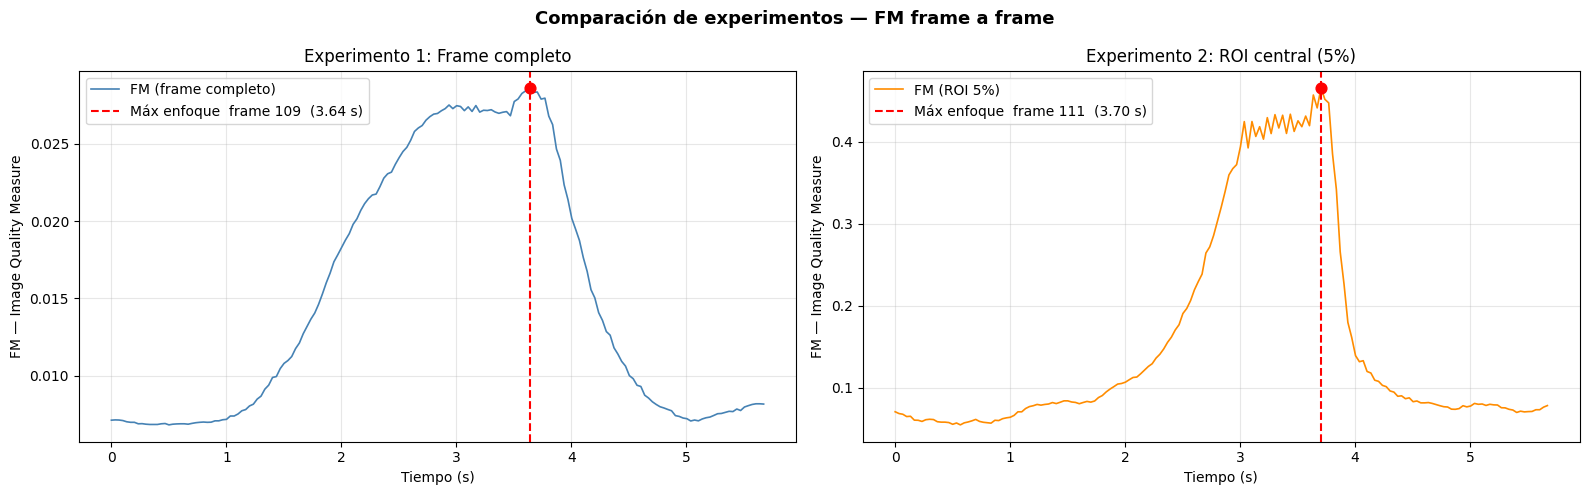

In [16]:
# ── Tabla comparativa ────────────────────────────────────────────────
print("=" * 55)
print(f"{'':30} {'Frame completo':>10} {'ROI 5%':>10}")
print("=" * 55)
print(f"  {'FM máximo':28} {fm_values_full[best_frame_full]:>10.6f} {fm_values_roi[best_frame_roi]:>10.6f}")
print(f"  {'Frame de máximo enfoque':28} {best_frame_full:>10} {best_frame_roi:>10}")
print(f"  {'Tiempo (s)':28} {best_frame_full/fps:>10.2f} {best_frame_roi/fps:>10.2f}")
print("=" * 55)

# ── Curvas FM lado a lado ────────────────────────────────────────────
time_axis = np.arange(len(fm_values_full)) / fps

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
fig.suptitle("Comparación de experimentos — FM frame a frame", fontsize=13, fontweight="bold")

# Panel izquierdo — frame completo
axes[0].plot(time_axis, fm_values_full, color="steelblue", linewidth=1.2, label="FM (frame completo)")
axes[0].axvline(best_frame_full / fps, color="red", linestyle="--", linewidth=1.5,
                label=f"Máx enfoque  frame {best_frame_full}  ({best_frame_full/fps:.2f} s)")
axes[0].scatter([best_frame_full / fps], [fm_values_full[best_frame_full]], color="red", zorder=5, s=60)
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("FM — Image Quality Measure")
axes[0].set_title("Experimento 1: Frame completo")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel derecho — ROI 5%
axes[1].plot(time_axis, fm_values_roi, color="darkorange", linewidth=1.2, label="FM (ROI 5%)")
axes[1].axvline(best_frame_roi / fps, color="red", linestyle="--", linewidth=1.5,
                label=f"Máx enfoque  frame {best_frame_roi}  ({best_frame_roi/fps:.2f} s)")
axes[1].scatter([best_frame_roi / fps], [fm_values_roi[best_frame_roi]], color="red", zorder=5, s=60)
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("FM — Image Quality Measure")
axes[1].set_title("Experimento 2: ROI central (5%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Los resultados obtenidos permiten comparar el comportamiento de ambos experimentos tanto cuantitativamente como visualmente.

En primer lugar, se observa una diferencia notable en la magnitud de FM: la ROI del 5% alcanza valores casi 16 veces superiores al frame completo (0.465 vs 0.028). Esto se explica por el contenido de la región analizada: la ROI quedó centrada sobre la zona más rica en detalle del pedal (el texto "PRECISION DRIVE", los bordes de los knobs y el mini switch central). Al medir solo esa región, el algoritmo captura una alta densidad de frecuencias altas. El frame completo, en cambio, incluye zonas con menos detalle que diluyen el valor de FM resultante.

En cuanto a la forma de las curvas, ambas presentan una campana clara y continua a lo largo del video, lo que valida que el algoritmo detecta correctamente el barrido de enfoque. Sin embargo, la curva de la ROI muestra oscilaciones más pronunciadas cerca del pico. Esto tiene sentido: al trabajar sobre una región pequeña, pequeñas variaciones de contenido o movimiento tienen mayor impacto relativo sobre el resultado.

Respecto a los frames detectados, ambos experimentos convergen en la misma zona temporal (frame 109 a 3.64 s vs frame 111 a 3.70 s). Comparando visualmente ambas imágenes, la diferencia de 2 frames no es perceptible: los dos frames se ven igual de nítidos, con el texto y los knobs bien definidos.

Finalmente, determinar cuál experimento es superior depende del caso de uso. Cuando el sujeto de interés está centrado en el encuadre, como en este video, la ROI resulta más sensible y precisa. Cuando el sujeto puede ubicarse en cualquier parte del frame, el experimento sobre el frame completo es más robusto, aunque pierde sensibilidad.